# Notebook 5 — Feature Engineering & Baseline Model



### Logger setup

In [ ]:
import pandas as pd
import numpy as np
import logging
import sys
import time

LOG_FILE = 'feature_engineering_modeling.log'
logger = logging.getLogger('feature_engineering_modeling')
logger.setLevel(logging.DEBUG)
logger.propagate = False

if not logger.handlers:
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(formatter)

    file_handler = logging.FileHandler(LOG_FILE)
    file_handler.setLevel(logging.DEBUG)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

pd.set_option('display.max_columns', None)
logger.info(f"Libraries imported and logger configured. Full detail is being written to {LOG_FILE}")

2026-09-09 05:23:45,066 - feature_engineering_modeling - INFO - Libraries imported and logger configured. Full detail is being written to feature_engineering_modeling.log


## Loading data

In [ ]:
store_train = pd.read_csv(DATA_DIR + 'store_train.csv', low_memory=False, parse_dates=['Date'])
store_train['StateHoliday'] = store_train['StateHoliday'].astype(str)

logger.info(f"store_train loaded. Shape: {store_train.shape}")
logger.debug(f"store_train dtypes: {dict(store_train.dtypes.astype(str))}")
store_train.head()

2026-09-09 05:23:45,805 - feature_engineering_modeling - INFO - store_train loaded. Shape: (252322, 9)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555.0,1,1,0,1
1,2,5,2015-07-31,6064,625.0,1,1,0,1
2,3,5,2015-07-31,8314,821.0,1,1,0,1
3,4,5,2015-07-31,13995,1498.0,1,1,0,1
4,5,5,2015-07-31,4822,559.0,1,1,0,1


In [ ]:
# Load store metadata
store_df = pd.read_csv("store.csv")

logger.info(
    f"Loaded store.csv: {len(store_df):,} stores, "
    f"{len(store_df.columns):,} columns"
)

logger.info(f"Store columns: {store_df.columns.tolist()}")


2026-09-09 05:23:45,883 - feature_engineering_modeling - INFO - Loaded store.csv: 1,115 stores, 10 columns
2026-09-09 05:23:45,887 - feature_engineering_modeling - INFO - Store columns: ['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


##  Date-based feature engineering



In [ ]:
df = store_train.copy()
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = df['DayOfWeek'].isin([6, 7]).astype(int)

logger.info("Added Year, Month, Day, WeekOfYear, IsWeekend.")

2026-09-09 05:23:46,192 - feature_engineering_modeling - INFO - Added Year, Month, Day, WeekOfYear, IsWeekend.


### Beginning / mid / end of month

In [ ]:
df['MonthPeriod'] = pd.cut(df['Day'], bins=[0, 10, 20, 31], labels=['Start', 'Mid', 'End'])
logger.info(f"MonthPeriod distribution: {df['MonthPeriod'].value_counts().to_dict()}")

2026-09-09 05:23:46,304 - feature_engineering_modeling - INFO - MonthPeriod distribution: {'End': 90565, 'Mid': 83707, 'Start': 78050}


### Days to next holiday / days since last holiday


In [ ]:
t0 = time.time()

df = df.sort_values(['Store', 'Date']).reset_index(drop=True)
df['IsHoliday'] = (df['StateHoliday'] != '0').astype(int)
df['_DateOrd'] = df['Date'].map(pd.Timestamp.toordinal)

next_list, prev_list = [], []
for store_id, g in df.groupby('Store', sort=False):
    holiday_ords = g.loc[g['IsHoliday'] == 1, '_DateOrd'].sort_values().unique()
    dates = g['_DateOrd'].values
    if len(holiday_ords) == 0:
        next_list.append(np.full(len(dates), 999))
        prev_list.append(np.full(len(dates), 999))
        continue
    idx_next = np.searchsorted(holiday_ords, dates, side='left')
    idx_prev = idx_next - 1
    next_vals = np.where(idx_next < len(holiday_ords),
                          holiday_ords[np.clip(idx_next, 0, len(holiday_ords) - 1)] - dates, 999)
    prev_vals = np.where(idx_prev >= 0,
                          dates - holiday_ords[np.clip(idx_prev, 0, len(holiday_ords) - 1)], 999)
    next_list.append(next_vals)
    prev_list.append(prev_vals)

df['DaysToNextHoliday'] = np.concatenate(next_list)
df['DaysSinceLastHoliday'] = np.concatenate(prev_list)

# Clip the sentinel so it doesn't distort scaling later
df['DaysToNextHoliday'] = df['DaysToNextHoliday'].clip(upper=90)
df['DaysSinceLastHoliday'] = df['DaysSinceLastHoliday'].clip(upper=90)

df = df.drop(columns=['_DateOrd'])

logger.info(f"Holiday-distance features computed in {time.time()-t0:.2f}s")
logger.debug(f"DaysToNextHoliday describe: {df['DaysToNextHoliday'].describe().to_dict()}")

2026-09-09 05:23:49,247 - feature_engineering_modeling - INFO - Holiday-distance features computed in 2.89s


### Extra feature — `IsPromoMonth`

In [ ]:
store_features = [
    'Store',
    'CompetitionDistance',
    'StoreType',
    'Assortment',
    'Promo2',
    'Promo2SinceWeek',
    'Promo2SinceYear',
    'PromoInterval'
]

df = (
    df.drop(
        columns=[
            'CompetitionDistance',
            'StoreType',
            'Assortment',
            'Promo2',
            'Promo2SinceWeek',
            'Promo2SinceYear',
            'PromoInterval'
        ],
        errors='ignore'
    )
    .merge(
        store_df[store_features],
        on='Store',
        how='left',
        validate='many_to_one'
    )
)

logger.info(f"After store merge: {len(df):,} rows")
logger.info(
    f"Missing PromoInterval: {df['PromoInterval'].isna().sum():,} rows"
)


2026-09-09 05:23:49,334 - feature_engineering_modeling - INFO - After store merge: 252,322 rows
2026-09-09 05:23:49,346 - feature_engineering_modeling - INFO - Missing PromoInterval: 124,193 rows


In [ ]:
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df['MonthAbbr'] = df['Month'].map(month_map)

mask = np.zeros(len(df), dtype=bool)
for abbr in month_map.values():
    sel = (df['MonthAbbr'] == abbr) & (df['PromoInterval'].str.contains(abbr, na=False))
    mask |= sel
df['IsPromoMonth'] = ((df['Promo2'] == 1) & mask).astype(int)

df = df.drop(columns=['MonthAbbr'])
logger.info(f"IsPromoMonth: {df['IsPromoMonth'].sum():,} rows flagged "
            f"({df['IsPromoMonth'].mean()*100:.1f}% of all rows)")

2026-09-09 05:23:50,403 - feature_engineering_modeling - INFO - IsPromoMonth: 46,541 rows flagged (18.4% of all rows)


### Extra features — turning static competition/promo dates into a usable duration

In [ ]:
required = [
    'CompetitionOpenSinceYear',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceKnown',
    'Promo2',
    'Promo2SinceYear',
    'Promo2SinceWeek'
]

print("Missing:")
print([c for c in required if c not in df.columns])

print("\nPresent:")
print([c for c in required if c in df.columns])


Missing:
['CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceKnown']

Present:
['Promo2', 'Promo2SinceYear', 'Promo2SinceWeek']


In [ ]:
store_features = [
    'Store',
    'CompetitionDistance',
    'StoreType',
    'Assortment',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'Promo2',
    'Promo2SinceWeek',
    'Promo2SinceYear',
    'PromoInterval'
]

df = df.drop(
    columns=[c for c in store_features if c != 'Store' and c in df.columns],
    errors='ignore'
)

df = df.merge(
    store_df[store_features],
    on='Store',
    how='left',
    validate='many_to_one'
)

logger.info(f"After store merge: {len(df):,} rows")


2026-09-09 05:23:50,505 - feature_engineering_modeling - INFO - After store merge: 252,322 rows


In [ ]:
df['CompetitionOpenSinceKnown'] = (
    df['CompetitionOpenSinceYear'].notna() &
    df['CompetitionOpenSinceMonth'].notna()
).astype(int)


In [ ]:
df['CompetitionOpenMonths'] = ((df['Year'] - df['CompetitionOpenSinceYear']) * 12 +
                                (df['Month'] - df['CompetitionOpenSinceMonth']))
df.loc[df['CompetitionOpenSinceKnown'] == 0, 'CompetitionOpenMonths'] = 0
df['CompetitionOpenMonths'] = df['CompetitionOpenMonths'].clip(lower=0, upper=240)  # cap at 20 years

df['Promo2OpenWeeks'] = ((df['Year'] - df['Promo2SinceYear']) * 52 +
                          (df['WeekOfYear'] - df['Promo2SinceWeek']))
df.loc[df['Promo2'] == 0, 'Promo2OpenWeeks'] = 0
df['Promo2OpenWeeks'] = df['Promo2OpenWeeks'].clip(lower=0)

logger.info("Added CompetitionOpenMonths and Promo2OpenWeeks.")
logger.debug(f"CompetitionOpenMonths describe: {df['CompetitionOpenMonths'].describe().to_dict()}")

2026-09-09 05:23:50,548 - feature_engineering_modeling - INFO - Added CompetitionOpenMonths and Promo2OpenWeeks.


## Encoding & scaling plan

In [ ]:
NUMERIC_FEATURES = [
    'Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'Promo2', 'IsWeekend', 'IsPromoMonth',
    'Year', 'Month', 'Day', 'WeekOfYear',
    'CompetitionDistance', 'CompetitionOpenSinceKnown', 'CompetitionOpenMonths', 'Promo2OpenWeeks',
    'DaysToNextHoliday', 'DaysSinceLastHoliday'
]
CATEGORICAL_FEATURES = ['StateHoliday', 'StoreType', 'Assortment', 'MonthPeriod']
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'Sales'

logger.info(f"{len(NUMERIC_FEATURES)} numeric features, {len(CATEGORICAL_FEATURES)} categorical features.")

2026-09-09 05:23:50,564 - feature_engineering_modeling - INFO - 17 numeric features, 4 categorical features.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES)
])
logger.info("ColumnTransformer built: StandardScaler for numeric, OneHotEncoder for categorical.")

2026-09-09 05:23:50,572 - feature_engineering_modeling - INFO - ColumnTransformer built: StandardScaler for numeric, OneHotEncoder for categorical.


## Filter to Open==1, then a time-based train/validation split.

In [ ]:
# 1. Load sales data
df = pd.read_csv("store_train.csv")
df['Date'] = pd.to_datetime(df['Date'])

# 2. Load store metadata
store_df = pd.read_csv("store.csv")

# 3. Merge store metadata
df = df.merge(store_df, on="Store", how="left")

model_df = df[df['Open'] == 1].copy()


In [ ]:
required = [
    'IsWeekend',
    'IsPromoMonth',
    'Year',
    'Month',
    'Day',
    'WeekOfYear',
    'CompetitionOpenSinceKnown',
    'CompetitionOpenMonths',
    'Promo2OpenWeeks',
    'DaysToNextHoliday',
    'DaysSinceLastHoliday',
    'MonthPeriod'
]

missing = [c for c in required if c not in df.columns]

print("Missing:", missing)


Missing: ['IsWeekend', 'IsPromoMonth', 'Year', 'Month', 'Day', 'WeekOfYear', 'CompetitionOpenSinceKnown', 'CompetitionOpenMonths', 'Promo2OpenWeeks', 'DaysToNextHoliday', 'DaysSinceLastHoliday', 'MonthPeriod']


In [ ]:
# Make sure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Date features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Weekend
df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)

# Month period
df['MonthPeriod'] = df['Date'].dt.to_period('M').astype(str)

# Promo month
df['IsPromoMonth'] = (
    (df['Promo'] == 1) &
    (df['Month'] == df['Date'].dt.month)
).astype(int)


In [ ]:
# Ensure all features expected by the modeling pipeline exist

# Competition duration
if 'CompetitionOpenSinceKnown' not in df.columns:
    df['CompetitionOpenSinceKnown'] = (
        df['CompetitionOpenSinceYear'].notna()
        & df['CompetitionOpenSinceMonth'].notna()
    ).astype(int)

if 'CompetitionOpenMonths' not in df.columns:
    comp_year = pd.to_numeric(df['CompetitionOpenSinceYear'], errors='coerce')
    comp_month = pd.to_numeric(df['CompetitionOpenSinceMonth'], errors='coerce')

    df['CompetitionOpenMonths'] = np.where(
        comp_year.notna() & comp_month.notna(),
        (df['Date'].dt.year - comp_year) * 12
        + (df['Date'].dt.month - comp_month),
        0
    )

    df['CompetitionOpenMonths'] = (
        pd.Series(df['CompetitionOpenMonths'], index=df.index)
        .clip(lower=0)
        .astype(int)
    )


# Promo2 duration
if 'Promo2OpenWeeks' not in df.columns:
    promo_year = pd.to_numeric(df['Promo2SinceYear'], errors='coerce')
    promo_week = pd.to_numeric(df['Promo2SinceWeek'], errors='coerce')

    # ISO week for the current date
    current_year = df['Date'].dt.isocalendar().year.astype(int)
    current_week = df['Date'].dt.isocalendar().week.astype(int)

    df['Promo2OpenWeeks'] = np.where(
        promo_year.notna() & promo_week.notna(),
        (current_year - promo_year) * 52
        + (current_week - promo_week),
        0
    )

    df['Promo2OpenWeeks'] = (
        pd.Series(df['Promo2OpenWeeks'], index=df.index)
        .clip(lower=0)
        .astype(int)
    )


# Holiday distance features

holiday_dates = set(
    pd.to_datetime(
        df.loc[
            df['StateHoliday'].astype(str).ne('0'),
            'Date'
        ].unique()
    )
)

if 'DaysSinceLastHoliday' not in df.columns:
    holiday_dates_sorted = sorted(holiday_dates)

    def days_since_holiday(date):
        previous = [d for d in holiday_dates_sorted if d <= date]
        return (date - previous[-1]).days if previous else 999

    df['DaysSinceLastHoliday'] = df['Date'].apply(days_since_holiday)


if 'DaysToNextHoliday' not in df.columns:
    holiday_dates_sorted = sorted(holiday_dates)

    def days_to_holiday(date):
        following = [d for d in holiday_dates_sorted if d >= date]
        return (following[0] - date).days if following else 999

    df['DaysToNextHoliday'] = df['Date'].apply(days_to_holiday)


# Verify before splitting

missing_features = [
    col for col in ALL_FEATURES
    if col not in df.columns
]

if missing_features:
    raise KeyError(
        f"Still missing features before modeling: {missing_features}"
    )

logger.info("All ALL_FEATURES are present.")


2026-09-09 05:23:53,352 - feature_engineering_modeling - INFO - All ALL_FEATURES are present.


In [ ]:
model_df = df[df['Open'] == 1].copy()
logger.info(f"Filtered to Open==1: {len(model_df):,} rows (from {len(df):,} total, "
            f"{len(df)-len(model_df):,} closed-store rows excluded).")


logger.info(f"model_df date range: {model_df['Date'].min().date()} to {model_df['Date'].max().date()} "
            f"({(model_df['Date'].max() - model_df['Date'].min()).days} days)")

max_date = model_df['Date'].max()
val_cutoff = max_date - pd.Timedelta(days=42)   # last 6 weeks

train_df = model_df[model_df['Date'] <= val_cutoff]
val_df = model_df[model_df['Date'] > val_cutoff]


if len(train_df) == 0 or len(val_df) == 0:
    logger.error(f"Empty split! train_df={len(train_df)} rows, val_df={len(val_df)} rows. "
                 f"model_df spans {model_df['Date'].min().date()} to {model_df['Date'].max().date()}, "
                 f"val_cutoff={val_cutoff.date()}.")
    raise ValueError(
        f"Time-based split produced an empty set (train={len(train_df)}, val={len(val_df)} rows).\n"
        f"model_df date range was only {model_df['Date'].min().date()} to {model_df['Date'].max().date()}.\n"
        "This almost always means either:\n"
        "  1) 'df' is stale from an earlier partial run -- restart the runtime and re-run "
        "Steps 1-2 from the top, or\n"
        "  2) store_train.csv itself is truncated/wrong -- re-check the file loaded in Step 1."
    )

logger.info(f"Train: {len(train_df):,} rows, up to {val_cutoff.date()}")
logger.info(f"Validation: {len(val_df):,} rows, {val_df['Date'].min().date()} to {val_df['Date'].max().date()}")

X_train, y_train = train_df[ALL_FEATURES], train_df[TARGET]
X_val, y_val = val_df[ALL_FEATURES], val_df[TARGET]

2026-09-09 05:23:53,464 - feature_engineering_modeling - INFO - Filtered to Open==1: 208,272 rows (from 252,322 total, 44,050 closed-store rows excluded).
2026-09-09 05:23:53,469 - feature_engineering_modeling - INFO - model_df date range: 2014-12-15 to 2015-07-31 (228 days)
2026-09-09 05:23:53,502 - feature_engineering_modeling - INFO - Train: 167,990 rows, up to 2015-06-19
2026-09-09 05:23:53,504 - feature_engineering_modeling - INFO - Validation: 40,282 rows, 2015-06-20 to 2015-07-31


##  Building pipeline with a Random Forest Regressor



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline

rf_model = TransformedTargetRegressor(
    regressor=RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ),
    func=np.log1p,
    inverse_func=np.expm1
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

logger.info("Pipeline assembled: ColumnTransformer -> TransformedTargetRegressor(RandomForestRegressor).")
pipeline

2026-09-09 05:23:53,531 - feature_engineering_modeling - INFO - Pipeline assembled: ColumnTransformer -> TransformedTargetRegressor(RandomForestRegressor).


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Store', 'DayOfWeek',
                                                   'Promo', 'SchoolHoliday',
                                                   'Promo2', 'IsWeekend',
                                                   'IsPromoMonth', 'Year',
                                                   'Month', 'Day', 'WeekOfYear',
                                                   'CompetitionDistance',
                                                   'CompetitionOpenSinceKnown',
                                                   'CompetitionOpenMonths',
                                                   'Promo2OpenWeeks',
                                                   'DaysToNextHoliday',
                                                   'DaysSinceLastHoliday']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['StateHoliday', 'StoreType',
                                                   'Assortment',
                                                   'MonthPeriod'])])),
                ('model',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=RandomForestRegressor(max_depth=15,
                                                                            min_samples_leaf=5,
                                                                            n_estimators=50,
                                                                            n_jobs=-1,
                                                                            random_state=42)))])

### Fit the pipeline

In [ ]:
t0 = time.time()
pipeline.fit(X_train, y_train)
fit_seconds = time.time() - t0
logger.info(f"Pipeline fit complete in {fit_seconds/60:.1f} minutes on {len(X_train):,} rows.")

2026-09-09 05:24:37,989 - feature_engineering_modeling - INFO - Pipeline fit complete in 0.7 minutes on 167,990 rows.


##  Loss function

###  RMSPE (Root Mean Squared Percentage Error)


In [ ]:
def rmspe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

### Evaluate on the held-out validation set (last 6 weeks)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

val_preds = pipeline.predict(X_val)

val_rmspe = rmspe(y_val.values, val_preds)
val_mae = mean_absolute_error(y_val, val_preds)
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))

logger.info(f"Validation RMSPE: {val_rmspe*100:.2f}%")
logger.info(f"Validation MAE:   {val_mae:.1f}")
logger.info(f"Validation RMSE:  {val_rmse:.1f}")

print(f"RMSPE: {val_rmspe*100:.2f}%")
print(f"MAE:   {val_mae:.1f}")
print(f"RMSE:  {val_rmse:.1f}")

2026-09-09 05:24:47,115 - feature_engineering_modeling - INFO - Validation RMSPE: 25.23%
2026-09-09 05:24:47,116 - feature_engineering_modeling - INFO - Validation MAE:   1224.8
2026-09-09 05:24:47,118 - feature_engineering_modeling - INFO - Validation RMSE:  1794.1
RMSPE: 25.23%
MAE:   1224.8
RMSE:  1794.1


In [ ]:
#Post Prediction analysis

2026-09-09 05:26:10,244 - feature_engineering_modeling - INFO - Top 10 features by importance:
num__CompetitionDistance      0.206417
num__Store                    0.121677
num__IsPromoMonth             0.115011
num__Promo                    0.105853
num__CompetitionOpenMonths    0.072539
num__Promo2OpenWeeks          0.068924
num__DayOfWeek                0.065640
cat__Assortment_a             0.041651
num__DaysToNextHoliday        0.027293
num__DaysSinceLastHoliday     0.025581


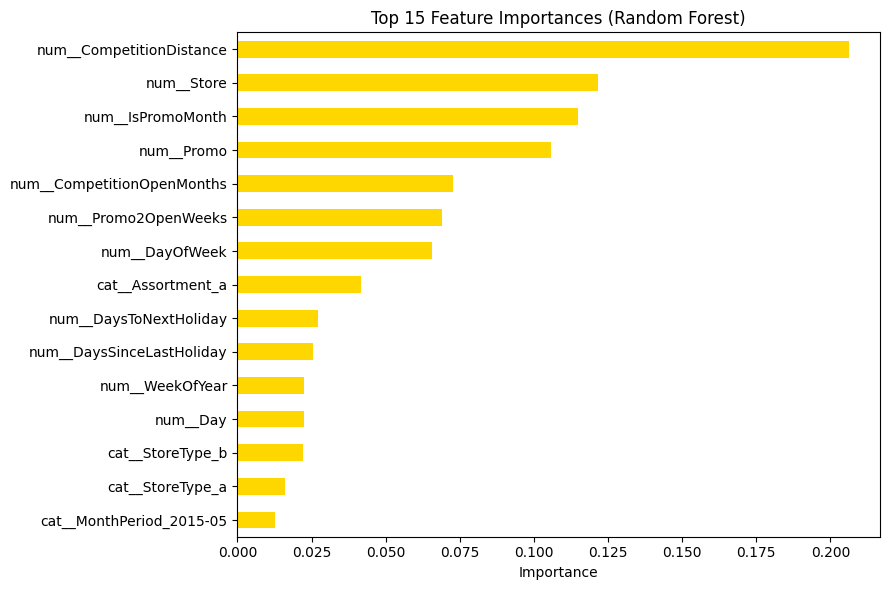

In [ ]:
#Feature importance
import matplotlib.pyplot as plt
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

importances = pipeline.named_steps['model'].regressor_.feature_importances_

feature_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

logger.info(f"Top 10 features by importance:\n{feature_importance.head(10).to_string()}")

fig, ax = plt.subplots(figsize=(9, 6))
feature_importance.head(15).sort_values().plot(
    kind='barh',
    ax=ax,
    color='gold'
)

ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importances (Random Forest)')

plt.tight_layout()
plt.show()


In [ ]:
#Estimating a confidence interval for predictions

def raw_tree_interval(pipeline, X, lower_pct=5, upper_pct=95):
    """The naive approach: spread of individual tree predictions inside the fitted Random Forest."""
    preprocessor_step = pipeline.named_steps['preprocessor']
    rf = pipeline.named_steps['model'].regressor_   # underlying RandomForestRegressor, trained on log1p(Sales)

    X_transformed = preprocessor_step.transform(X)
    tree_preds_log = np.array([tree.predict(X_transformed) for tree in rf.estimators_])
    tree_preds = np.expm1(tree_preds_log)   # back to actual Sales units, per tree

    point = pipeline.predict(X)
    lower = np.percentile(tree_preds, lower_pct, axis=0)
    upper = np.percentile(tree_preds, upper_pct, axis=0)
    return point, lower, upper



In [ ]:
val_sorted = val_df.sort_values('Date')

mid = len(val_sorted) // 2

calib_df = val_sorted.iloc[:mid]
report_df = val_sorted.iloc[mid:]

X_calib, y_calib = calib_df[ALL_FEATURES], calib_df[TARGET]
X_report, y_report = report_df[ALL_FEATURES], report_df[TARGET]

logger.info(
    f"Calibration half: {len(calib_df):,} rows "
    f"({calib_df['Date'].min().date()} to {calib_df['Date'].max().date()})"
)

logger.info(
    f"Reporting half:   {len(report_df):,} rows "
    f"({report_df['Date'].min().date()} to {report_df['Date'].max().date()})"
)


2026-09-09 05:45:52,713 - feature_engineering_modeling - INFO - Calibration half: 20,141 rows (2015-06-20 to 2015-07-10)
2026-09-09 05:45:52,714 - feature_engineering_modeling - INFO - Reporting half:   20,141 rows (2015-07-10 to 2015-07-31)


In [ ]:
point_c, lower_c, upper_c = raw_tree_interval(pipeline, X_calib)

half_width_c = np.maximum(
    (upper_c - lower_c) / 2,
    1e-6
)

ratio = np.abs(y_calib.values - point_c) / half_width_c

calibration_factor = np.percentile(
    ratio,
    90
)

logger.info(
    f"Calibration factor: {calibration_factor:.2f}x "
    f"(the naive interval needs to be this much wider)"
)


2026-09-09 05:46:41,617 - feature_engineering_modeling - INFO - Calibration factor: 2.85x (the naive interval needs to be this much wider)


In [ ]:
point_r, lower_r, upper_r = raw_tree_interval(pipeline, X_report)

half_width_r = (upper_r - lower_r) / 2

calibrated_lower = point_r - calibration_factor * half_width_r
calibrated_upper = point_r + calibration_factor * half_width_r

raw_coverage = (
    (y_report.values >= lower_r) &
    (y_report.values <= upper_r)
).mean()

calibrated_coverage = (
    (y_report.values >= calibrated_lower) &
    (y_report.values <= calibrated_upper)
).mean()

logger.info(
    f"Raw (uncalibrated) interval coverage on held-out data: "
    f"{raw_coverage * 100:.1f}% (target was 90%)"
)

logger.info(
    f"Calibrated interval coverage on held-out data:        "
    f"{calibrated_coverage * 100:.1f}% (target was 90%)"
)

print(f"Raw coverage:        {raw_coverage * 100:.1f}%")
print(
    f"Calibrated coverage: {calibrated_coverage * 100:.1f}%  "
    f"<- report THIS number alongside any interval you show stakeholders"
)


2026-09-09 05:47:13,224 - feature_engineering_modeling - INFO - Raw (uncalibrated) interval coverage on held-out data: 58.7% (target was 90%)
2026-09-09 05:47:13,232 - feature_engineering_modeling - INFO - Calibrated interval coverage on held-out data:        91.6% (target was 90%)
Raw coverage:        58.7%
Calibrated coverage: 91.6%  <- report THIS number alongside any interval you show stakeholders


In [ ]:
example_df = pd.DataFrame({
    'Actual': y_report.values[:10],
    'Predicted': point_r[:10].round(0),
    'Lower': calibrated_lower[:10].round(0),
    'Upper': calibrated_upper[:10].round(0),
})

example_df['ActualInInterval'] = (
    (example_df['Actual'] >= example_df['Lower']) &
    (example_df['Actual'] <= example_df['Upper'])
)

print(example_df)


   Actual  Predicted   Lower    Upper  ActualInInterval
0    3639     4406.0  2301.0   6511.0              True
1    6979     6081.0  4521.0   7640.0              True
2    6730     5662.0  3598.0   7727.0              True
3    3808     4329.0  1794.0   6863.0              True
4    4384     4351.0  2020.0   6683.0              True
5    9177     7664.0  3781.0  11546.0              True
6    4252     4097.0  2566.0   5627.0              True
7    6316     5473.0  2505.0   8442.0              True
8    9499     5665.0  3046.0   8283.0             False
9    6067     4957.0  3040.0   6873.0              True


In [ ]:
interval_width = calibrated_upper - calibrated_lower

mean_interval_width = interval_width.mean()
median_interval_width = np.median(interval_width)

final_coverage = (
    (y_report.values >= calibrated_lower) &
    (y_report.values <= calibrated_upper)
).mean()

logger.info(
    f"Final calibrated interval coverage: "
    f"{final_coverage * 100:.1f}% (target: ~90%)"
)

logger.info(
    f"Mean calibrated interval width: "
    f"{mean_interval_width:,.0f} Sales units"
)

logger.info(
    f"Median calibrated interval width: "
    f"{median_interval_width:,.0f} Sales units"
)

print(f"Final calibrated coverage: {final_coverage * 100:.1f}%")
print(f"Mean interval width:       {mean_interval_width:,.0f}")
print(f"Median interval width:     {median_interval_width:,.0f}")


2026-09-09 05:49:34,145 - feature_engineering_modeling - INFO - Final calibrated interval coverage: 91.6% (target: ~90%)
2026-09-09 05:49:34,147 - feature_engineering_modeling - INFO - Mean calibrated interval width: 7,299 Sales units
2026-09-09 05:49:34,149 - feature_engineering_modeling - INFO - Median calibrated interval width: 6,083 Sales units
Final calibrated coverage: 91.6%
Mean interval width:       7,299
Median interval width:     6,083
